In [27]:
from typing import TypedDict, List
from langgraph.graph import StateGraph
import math

In [14]:
class AgentState(TypedDict):
    name : str
    operation : str
    values : List[int]
    message : str

In [20]:
def calculator(state: AgentState) -> AgentState:
    if state['operation'] == "+":
        state['message'] = f"Hi {state['name']}, your answer is: {sum(state['values'])}"
    elif state['operation'] == "*":
        state['message'] = f"Hi {state['name']}, your answer is: {math.prod(state['values'])}"
    return state

In [21]:
graph = StateGraph(AgentState)
graph.add_node("Calculator", calculator)
graph.set_entry_point("Calculator")
graph.set_finish_point("Calculator")
app = graph.compile()

In [24]:
result = app.invoke({"name":"Bob", "operation":"*", "values":[1, 2, 3, 4]})
result["message"]

'Hi Bob, your answer is: 24'

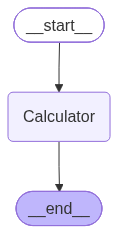

In [26]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))